In [1]:
!pip install tensorflow
!pip install pandas numpy scikit-learn matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Input, Conv1DTranspose
from tensorflow.keras.callbacks import EarlyStopping

path = 'data/' 

try:
    vib_normal = pd.read_csv(path + 'vibration_normal.csv', parse_dates=['Time'])
    vib_anomaly = pd.read_csv(path + 'vibration_anomaly.csv', parse_dates=['Time'])
    cur_normal = pd.read_csv(path + 'current_normal.csv', parse_dates=['Time'])
    cur_anomaly = pd.read_csv(path + 'current_anomaly.csv', parse_dates=['Time'])
    print("성공적으로 데이터를 로드했습니다.")
    print(f"정상 데이터 크기: {vib_normal.shape}, 이상 데이터 크기: {vib_anomaly.shape}")
except FileNotFoundError:
    print("오류: 파일을 찾을 수 없습니다. 'data' 폴더와 파일명을 다시 확인하세요.")

성공적으로 데이터를 로드했습니다.
정상 데이터 크기: (1774, 513), 이상 데이터 크기: (16, 513)


In [3]:
vib_train = vib_normal.iloc[:1758, 1:].values 
vib_test = pd.concat([vib_normal.iloc[1758:, 1:], vib_anomaly.iloc[:, 1:]], ignore_index=True).values

cur_train = cur_normal.iloc[:8170, 1:].values
cur_test = pd.concat([cur_normal.iloc[8170:, 1:], cur_anomaly.iloc[:, 1:]], ignore_index=True).values

scaler = StandardScaler()
vib_train_scaled = scaler.fit_transform(vib_train)
vib_test_scaled = scaler.transform(vib_test)

cur_train_scaled = scaler.fit_transform(cur_train)
cur_test_scaled = scaler.transform(cur_test)

vib_train_final = vib_train_scaled.reshape(vib_train_scaled.shape[0], vib_train_scaled.shape[1], 1)
vib_test_final = vib_test_scaled.reshape(vib_test_scaled.shape[0], vib_test_scaled.shape[1], 1)

cur_train_final = cur_train_scaled.reshape(cur_train_scaled.shape[0], cur_train_scaled.shape[1], 1)
cur_test_final = cur_test_scaled.reshape(cur_test_scaled.shape[0], cur_test_scaled.shape[1], 1)

print("전처리 및 차원 변환 완료:")
print(f"최종 훈련 데이터 크기: {vib_train_final.shape}")

전처리 및 차원 변환 완료:
최종 훈련 데이터 크기: (1758, 512, 1)


In [ ]:
def build_model(input_data):
    model = Sequential([
        Input(shape=(input_data.shape[1], input_data.shape[2])),
        Conv1D(filters=64, kernel_size=input_data.shape[1]//64, padding='same', strides=2, activation='relu'),
        Conv1D(filters=32, kernel_size=input_data.shape[1]//64, padding='same', activation='relu'),
        Conv1DTranspose(filters=64, kernel_size=input_data.shape[1]//64, padding='same', strides=2, activation='relu'),
        Conv1DTranspose(filters=1, kernel_size=input_data.shape[1]//64, padding='same')
    ])
    return model

vib_model = build_model(vib_train_final)
vib_model.compile(optimizer='adam', loss='mae')

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

vib_history = vib_model.fit(
    vib_train_final, vib_train_final, 
    epochs=50, 
    validation_split=0.2, 
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.2720 - val_loss: 0.0733
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0586 - val_loss: 0.0454
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0373 - val_loss: 0.0408
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0434 - val_loss: 0.0389
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0318 - val_loss: 0.0349
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0298 - val_loss: 0.0411
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0282 - val_loss: 0.0351
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0301 - val_loss: 0.0267
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0251 - val_loss: 0.0447
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0270 - val_loss: 0.0325
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0300 - val_loss: 0.0295
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0

In [5]:
vib_train_pred = vib_model.predict(vib_train_final)
vib_train_mae = np.mean(np.abs(vib_train_pred - vib_train_final), axis=1)

threshold = np.mean(vib_train_mae) + 3*np.std(vib_train_mae)

vib_test_pred = vib_model.predict(vib_test_final)
vib_test_mae = np.mean(np.abs(vib_test_pred - vib_test_final), axis=1)

print(f"결정된 3-시그마 임계치: {threshold}")

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
결정된 3-시그마 임계치: 0.0389785185720597


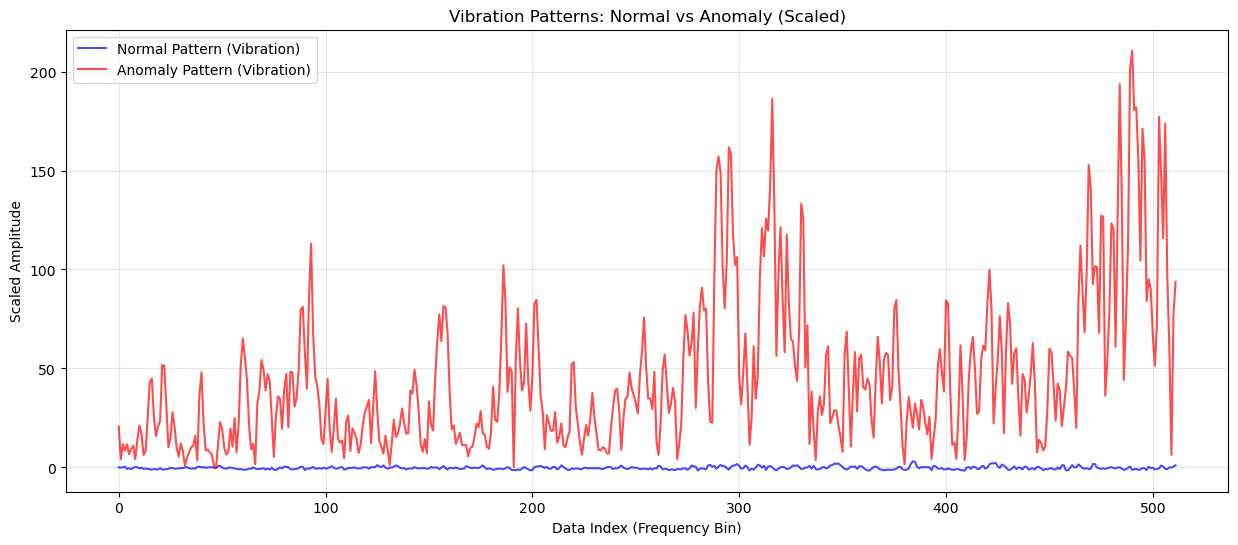

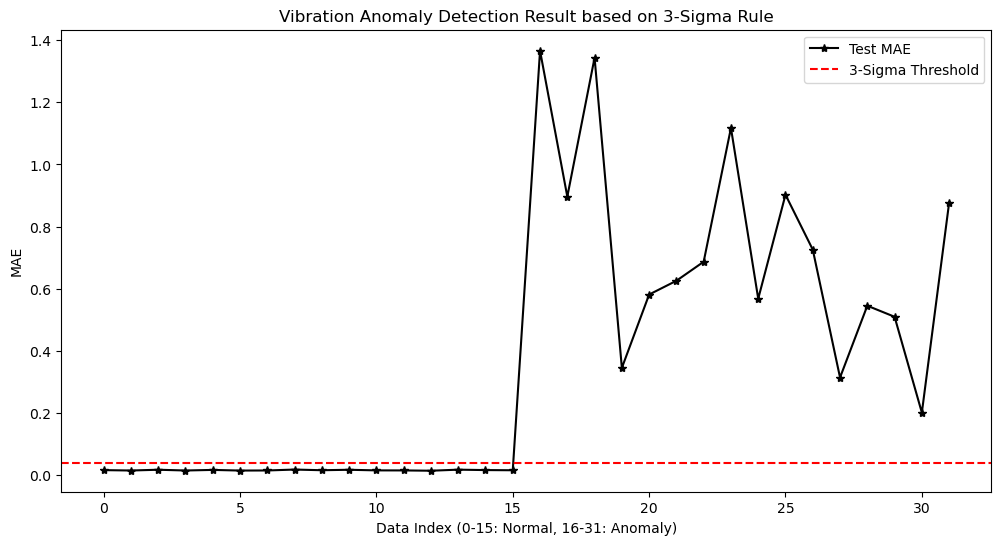

In [6]:
plt.figure(figsize=(15, 6))
plt.plot(vib_train_scaled[0], label='Normal Pattern (Vibration)', color='blue', alpha=0.7)
plt.plot(vib_test_scaled[-1], label='Anomaly Pattern (Vibration)', color='red', alpha=0.7)
plt.title('Vibration Patterns: Normal vs Anomaly (Scaled)')
plt.xlabel('Data Index (Frequency Bin)')
plt.ylabel('Scaled Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(vib_test_mae, marker='*', color='black', label='Test MAE')
plt.axhline(y=threshold, color='red', linestyle='--', label='3-Sigma Threshold')
plt.title('Vibration Anomaly Detection Result based on 3-Sigma Rule')
plt.xlabel('Data Index (0-15: Normal, 16-31: Anomaly)')
plt.ylabel('MAE')
plt.legend()
plt.show()

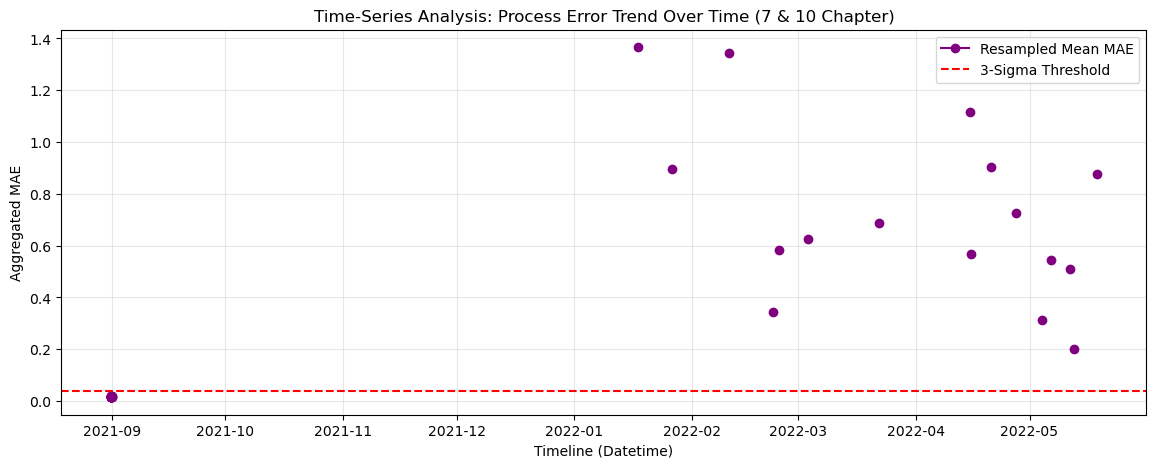

In [9]:
test_times = pd.concat([vib_normal.iloc[1758:, 0], vib_anomaly.iloc[:, 0]], ignore_index=True)


vib_test_mae_1d = vib_test_mae.flatten()


ts_analysis_df = pd.DataFrame({
    'Timestamp': test_times,
    'Reconstruction_Loss': vib_test_mae_1d 
})

ts_analysis_df.set_index('Timestamp', inplace=True)

ts_resampled = ts_analysis_df.resample('10s').mean()

plt.figure(figsize=(14, 5))
plt.plot(ts_resampled.index, ts_resampled['Reconstruction_Loss'], marker='o', color='purple', label='Resampled Mean MAE')
plt.axhline(y=threshold, color='red', linestyle='--', label='3-Sigma Threshold')
plt.title('Time-Series Analysis: Process Error Trend Over Time (7 & 10 Chapter)')
plt.xlabel('Timeline (Datetime)')
plt.ylabel('Aggregated MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

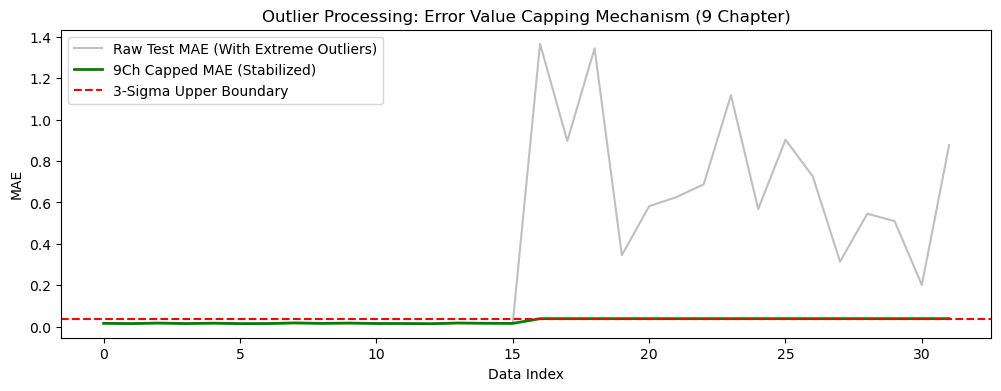

In [10]:
vib_test_mae_cleaned = np.where(vib_test_mae > threshold, threshold, vib_test_mae)

plt.figure(figsize=(12, 4))
plt.plot(vib_test_mae, label='Raw Test MAE (With Extreme Outliers)', color='gray', alpha=0.5)
plt.plot(vib_test_mae_cleaned, label='9Ch Capped MAE (Stabilized)', color='green', linewidth=2)
plt.axhline(y=threshold, color='red', linestyle='--', label='3-Sigma Upper Boundary')
plt.title('Outlier Processing: Error Value Capping Mechanism (9 Chapter)')
plt.xlabel('Data Index')
plt.ylabel('MAE')
plt.legend()
plt.show()